In [1]:
%load_ext autoreload
%autoreload 2
import sys
import interpax

sys.path.append("../modules")
sys.path.append("../modules/TransdimensionalSplineFitting")
from loguru import logger
import numpy as np
import gwpopulation
gwpopulation.set_backend('jax')
from gwpopulation.models.mass import SinglePeakSmoothedMassDistribution
from gwpopulation.models.redshift import MadauDickinsonRedshift
from spline_redshift import createSplineRedshift
import pickle
import cloudpickle
from pathlib import Path

import json

import westley
from popstock_tsf_helper import (create_injected_OmegaGW,
                                 get_sigma_from_noise_curves,
                                 create_popOmegaGW)
import transdimensional_spline_fitting as tsf
from tsf_models import RedshiftSampler, RedshiftSamplerJAX,WestleyRedshiftSamplerJAX
import argparse
import lal
lal.swig_redirect_standard_output_error(False)

import matplotlib.pyplot as plt
import jax

/Users/patrickmeyers/miniforge3/envs/westley_fitter/lib/python3.10/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
import lal
lal.swig_redirect_standard_output_error(False)

False

In [3]:
from jax import lax

def propagate_last_selected(x, a, mask):
    """
    Go through and anywhere that mask is set to zero, set that value
    to the last value that was turned on. i.e.

    x = [1, 2, 3, 4]
    y = [1, 4, 9, 16]
    mask = [1., 0., 0., 1]

    then:
    
    xout = [1, 1, 1, 4]
    yout = [1, 1, 1, 16]

    We use this to handle the interpolation with JAX because JAX doesn't
    want array sizes to change. So when `xout` and `yout` are passed to the 
    interpolator, the values they now have functionally make it as if we were
    just using
    [1, 4]
    [1, 16]
    as the points we were interpolating between. But we just haven't changed the array size. 
    """

    first_idx = jnp.argmax(mask)
    def step(carry, inputs):
        x_carry, a_carry = carry
        x_i, a_i, m_i = inputs
        new_x = jnp.where(m_i, x_i, x_carry)
        new_a = jnp.where(m_i, a_i, a_carry)
        return (new_x, new_a), (new_x, new_a)
    
    init = (x[first_idx], a[first_idx])
    _, (out_x, out_a) = jax.lax.scan(step, init, xs=(x, a, mask))
    return out_x, out_a

jpls = jax.jit(propagate_last_selected)

# Set parameters

Note that I've changed the parameters here a bit. The $\alpha$ and $\beta$ were set to values from Tom's paper for redshift. But here they are parameters for the PLPP mass distribution (See GWTC-2 paper). So I've set these values to match the GWTC-2 PLPP 1D medians. 

For the Redshift distribution, somewhat confusingly, in the code itself [here](https://github.com/ColmTalbot/gwpopulation/blob/main/gwpopulation/models/redshift.py#L230). the M-D parameters are not the same as what we've often used (by name), or as they're named in the GWTC-2 paper! $\gamma$ is the index on the way up, $\gamma - \kappa$ is the index on the way down. This is defined differently than in [Tom's](https://arxiv.org/pdf/2003.12152) paper, where the $\gamma \rightarrow \alpha$ and $\kappa \rightarrow \alpha + \beta$. 

The other issue here is that I'm not sure the mass parameters were correct. 

In [11]:
Lambda_0 =  {'alpha': 2.63, 'beta': 1.26, 'delta_m': 5., 'lam': 0.1,
            'mmax': 86., 'mmin': 4.6, 'mpp': 33., 'sigpp':5.7, 'gamma': 2.7,
            'kappa': 6.1, 'z_peak': 2.4, 'rate': 25}

In [5]:
mass_obj = SinglePeakSmoothedMassDistribution()
redshift_obj = MadauDickinsonRedshift(z_max=10)

In [43]:
# 4 hours for now...

Tobs = 86400 * 365.25 * (1./365.25)  * 4/24
freqs = np.arange(10, 200, 0.25)
sigma = get_sigma_from_noise_curves(['CE'], freqs, Tobs)

max_knots=30

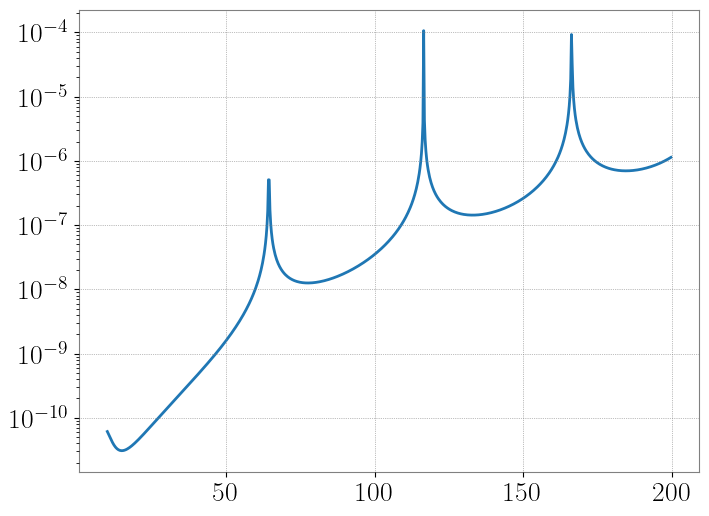

In [7]:
fig, ax = plt.subplots()
ax.plot(freqs, sigma)
plt.yscale("log")
plt.show()

In [8]:
xvals, spline_pop, injected_pop, amplitudes, configuration, Lambda_start = \
    create_injected_OmegaGW(freqs, Lambda_0, 10_000,
                            mass_obj, redshift_obj, backend='jax', max_knots=max_knots)

Initializing with the following models: 
mass: <gwpopulation.models.mass.SinglePeakSmoothedMassDistribution object at 0x112f8bcd0>
redshift: <gwpopulation.models.redshift.MadauDickinsonRedshift object at 0x327153100>
Using 1000000, got 3333 out of target 10000 samples after iteration 0
Efficiency: 0.003333, trying 2000300 samples in next iteration
-----------------------------------------------------------
Using 2000300, got 10168 out of target 10000 samples after iteration 1
Efficiency: 0.0034169874518822176, trying 926254 samples in next iteration
-----------------------------------------------------------
Drawing redshift samples
{'gamma': 2.7, 'kappa': 5.0, 'z_peak': 2.4}


16:47 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


Using multiprocessing, no status bar currently supported... 
Initializing with the following models: 
mass: <gwpopulation.models.mass.SinglePeakSmoothedMassDistribution object at 0x112f8bcd0>
redshift: <spline_redshift.createSplineRedshift.<locals>.SplineRedshift object at 0x364dc6a70>
Using 1000000, got 3348 out of target 10000 samples after iteration 0
Efficiency: 0.003348, trying 1986857 samples in next iteration
-----------------------------------------------------------
Using 1986857, got 10155 out of target 10000 samples after iteration 1
Efficiency: 0.00342601405133837, trying 931986 samples in next iteration
-----------------------------------------------------------
Drawing redshift samples


16:48 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


{'amplitudes0': np.float64(1.537952182203794), 'amplitudes1': np.float64(3.0094704598334423), 'amplitudes2': np.float64(5.040100829781302), 'amplitudes3': np.float64(7.481949252810929), 'amplitudes4': np.float64(9.983491703864903), 'amplitudes5': np.float64(12.064753862107823), 'amplitudes6': np.float64(13.33457520536123), 'amplitudes7': np.float64(13.683679458105086), 'amplitudes8': np.float64(13.277299267072058), 'amplitudes9': np.float64(12.39727373525172), 'amplitudes10': np.float64(11.299377770564844), 'amplitudes11': np.float64(10.157571084017263), 'amplitudes12': np.float64(9.068842016807752), 'amplitudes13': np.float64(8.077344723498605), 'amplitudes14': np.float64(7.196570047831486), 'amplitudes15': np.float64(6.424291447531571), 'amplitudes16': np.float64(5.7512831158026545), 'amplitudes17': np.float64(5.165965083260132), 'amplitudes18': np.float64(4.656632620427462), 'amplitudes19': np.float64(4.212581233079032), 'amplitudes20': np.float64(3.8242915998471805), 'amplitudes21'

In [9]:
%%timeit
spline_pop.calculate_omega_gw(Lambda_start)

38.5 ms ± 1.04 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


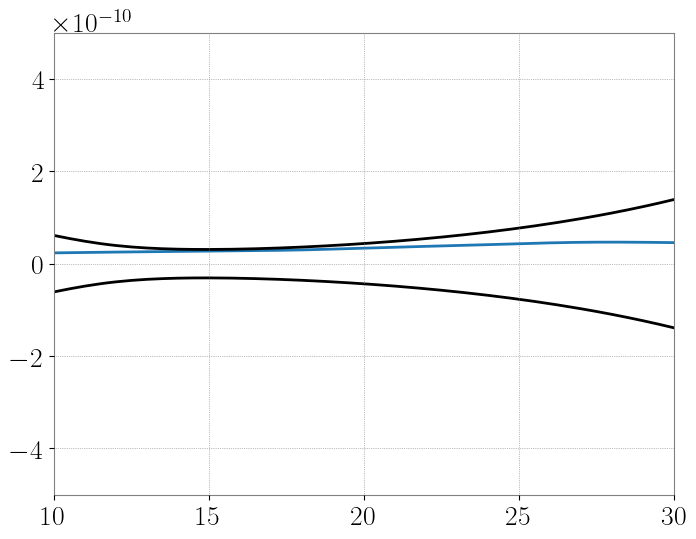

In [10]:
spline_pop.calculate_omega_gw(Lambda_start)
injected_pop.calculate_omega_gw(Lambda_start)
plt.plot(freqs, spline_pop.omega_gw - injected_pop.omega_gw)
# plt.plot(freqs, )
plt.plot(freqs, sigma, c='k')
plt.plot(freqs, -sigma, c='k')
plt.xlim(10, 30)
plt.ylim(-5e-10, 5e-10)
plt.show()

# Pull out the logic in popstock to be able to "jaxify" things. 

Basically, we pull out the mass and spin probabilities, which will stay the same no matter what because we are not changing those parameters. JAX wasn't liking recalculating those, but they also slow things down to recalculate every time if the parameters aren't changing. 

We then have to do some "functional programming" to make things that are pre-calculated defined in the function itself. We end up outputting a single function that takes in the same parameter dictionary as before, but calculates omega_gw.

In [12]:
import jax.numpy as jnp

from popstock.constants import H0



def make_calculate_omgw(spline_pop):

    H0_si = H0.si.value
    samples = spline_pop.proposal_samples
    p_masses = spline_pop.calculate_p_masses(samples, {key: Lambda_0[key] for key in spline_pop.model_args['mass']})
    p_spins = spline_pop.calculate_p_spin_models(samples, Lambda_0)
    def calculate_probabilities(Lambda_redshift):
        p_redshift = spline_pop.calculate_p_z(samples, Lambda_redshift)
        return p_masses*p_spins*p_redshift
    
    def calculate_weights(Lambda):
        probabilities = calculate_probabilities(Lambda)
        weights = (probabilities / spline_pop.pdraws)
        weights = jnp.where(probabilities!=0.0, weights, 0)
        return weights
    def omegagw(Lambda):
        redshift_model_norm_in_Gpc3 = spline_pop.models['redshift'].normalisation(Lambda)/1.e9
        Rate_norm_in_Gpc3_per_seconds = Lambda['rate']/(60*60*24*365)
        Rate_norm = redshift_model_norm_in_Gpc3 * Rate_norm_in_Gpc3_per_seconds
        weights = calculate_weights(Lambda)
        weighted_energy = jnp.nansum(weights[:, None] * spline_pop.wave_energies, axis=0) / weights.size
        conv = spline_pop.frequency_array_xp**3 * 4. * jnp.pi**2 / (3 * H0_si**2)
        return Rate_norm * conv * weighted_energy
    return omegagw
import jax
calc_omgw = make_calculate_omgw(spline_pop)
jco = jax.jit(calc_omgw)
calc_omgw_v_and_grad = jax.value_and_grad(calc_omgw)

In [13]:
for ii in range(max_knots):
    Lambda_start[f'configuration{ii}'] = 1.

In [14]:
fake_data = np.random.randn(freqs.size) * sigma + injected_pop.omega_gw

data_object = tsf.SmoothCurveDataObj(freqs, fake_data, sigma)

# Let's now use the new Westley sampler.

Because we have a separate function that takes the redshift parameters and calculates omega_gw we have to pass that to the sampler. This new class is defined in `tsf_models` and it reimplements a few things to make it self-consistent. 

First: It reimplements the death proposal to make sure the end knots are always turned on.

Second: It reimplements the `evaluate_interp_model` just to make sure that its interpolation logic is similar to the logic that is in the `SplineRedshiftModel` in `spline_redshift.py`. I basically copied one over to the other.

If you look at those functions you will see things like `if backend=='jax'`, etc. This is to handle the fact taht you should be able to run the code without jax if you don't want it. The models should still work. 

In [15]:
wes_rs_sampler_jax = WestleyRedshiftSamplerJAX(jax.jit(calc_omgw), spline_pop, Lambda_start, data_object, max_knots,
                             [0.01, 10], [0, 30],
                             min_knots=0, birth_gauss_scalefac=1, birth_uniform_frac=0.3)

In [16]:
wes_rs_sampler_jax.state

SplineState(configuration=array([ True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True]), heights=array([15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15.,
       15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15.,
       15., 15., 15., 15., 15., 15., 15., 15.]), knots=array([0.17748333, 0.51045   , 0.84341667, 1.17638333,
       1.50935   , 1.84231667, 2.17528333, 2.50825   ,
       2.84121667, 3.17418333, 3.50715   , 3.84011667,
       4.17308333, 4.50605   , 4.83901667, 5.17198333,
       5.50495   , 5.83791667, 6.17088333, 6.50385   ,
       6.83681667, 7.16978333, 7.50275   , 7.83571667,
       8.16868333, 8.50165   , 8.83461667, 9.16758333,
       9.50055   , 9.83351667]), log_likelihood=Array(-22694.715044, dtype=float64))

In [17]:
%%timeit
wes_rs_sampler_jax.ln_likelihood(wes_rs_sampler_jax.state.configuration,
                             wes_rs_sampler_jax.state.heights,
                             wes_rs_sampler_jax.state.knots)

3.64 ms ± 74.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [18]:
# with jax.profiler.trace("./jax-trace", create_perfetto_link=False):
#     for ii in range(10):
#         calc_omgw(Lambda_start)

In [19]:
import westley.parallel_tempering as wpt

In [20]:
pt_sampler = wpt.ParallelTempering(wes_rs_sampler_jax, n_temps=10, max_temp=10000.0, adapt_ladder=True, t_0=1000, nu=30)

## Results are different now (sorry)

Because things are parallel tempered, there are `n_temps` chains. Get the first one (the one with T=1, i.e. the chain that has the actual posterior) with:

`cold_chain = results.get_chain_results(0)`

Then this is a list of steps of the MCMC. Each entry of the list has a "state" of the sampler. Which in this case is the log_likelihood, knots, heights, and configuration. So:

`cold_chain[0].state.configuration`, for example is the configuration for the very first step. I will work towards making the output more user-friendly, but below is an example of how to get the number of knots out, and plot the results. 

In [21]:
results = pt_sampler.sample(10_000, swap_interval=20)

2025-05-09 16:48:40.201 | INFO     | westley.parallel_tempering:sample:118 - Initializing chains
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [06:44<00:00, 24.71it/s]
2025-05-09 16:55:25.010 | INFO     | westley.parallel_tempering:sample:153 - Swap rate between chains 0 and 1: 0.528
2025-05-09 16:55:25.010 | INFO     | westley.parallel_tempering:sample:153 - Swap rate between chains 1 and 2: 0.646
2025-05-09 16:55:25.010 | INFO     | westley.parallel_tempering:sample:153 - Swap rate between chains 2 and 3: 0.692
2025-05-09 16:55:25.010 | INFO     | westley.parallel_tempering:sample:153 - Swap rate between chains 3 and 4: 0.640
2025-05-09 16:55:25.011 | INFO     | westley.parallel_tempering:sample:153 - Swap rate between chains 4 and 5: 0.612
2025-05-09 16:55:25.011 | INFO     | westley.parallel_tempering:sample:153 - Swap rate between chains 5 a

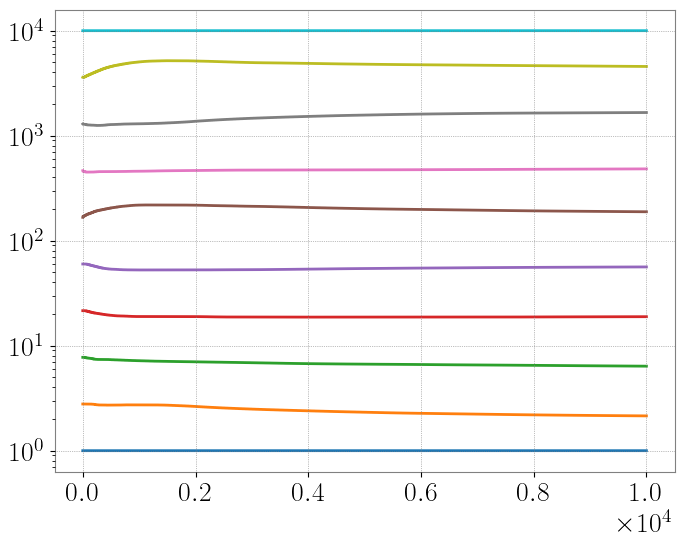

In [22]:
plt.plot(np.array(results.temperature_history))
plt.yscale("log")

In [23]:
# get the cold chain
cold_chain = results.get_chain_results(0)

In [24]:
nknots = [cold_chain[ii].state.configuration.sum() for ii in range(len(cold_chain))]
print(min(nknots))

2


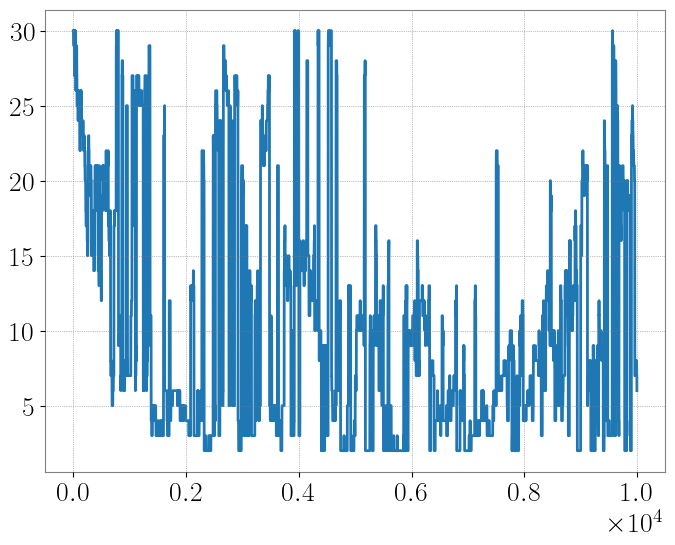

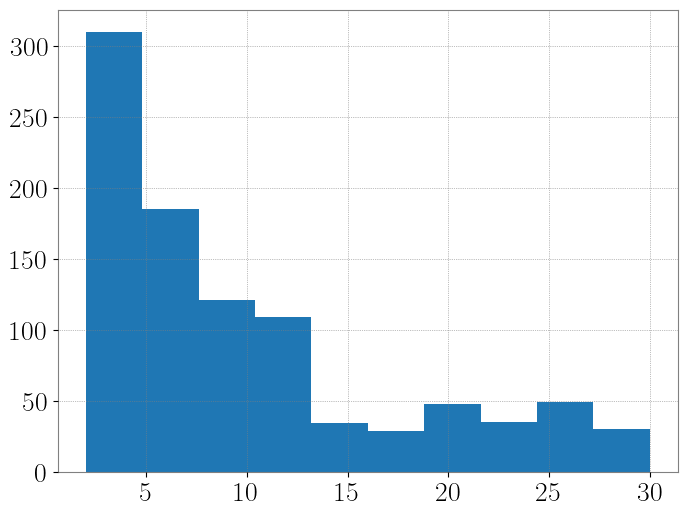

In [25]:
plt.plot(nknots)
plt.show()

plt.hist(nknots[500::10])
plt.show()

/Users/patrickmeyers/miniforge3/envs/westley_fitter/lib/python3.10/site-packages/gwpy/plot/axes.py:571: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return super().legend(*args, **kwargs)


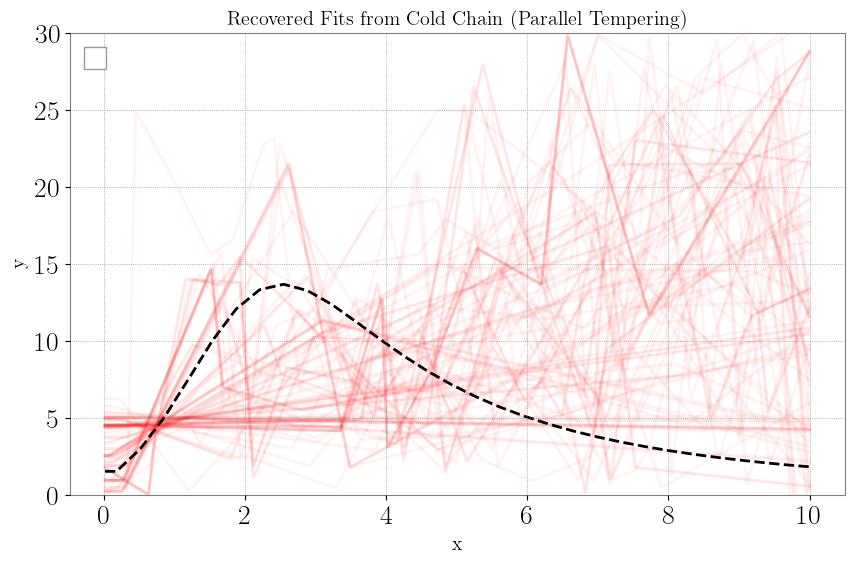

[[ 1.0545751   1.0545751   1.0545751  ...  3.45761112
   3.37735505  3.20798366]
 [ 4.90462342  4.90462342  4.90462342 ... 22.29916369
  22.36216662 22.54991953]]


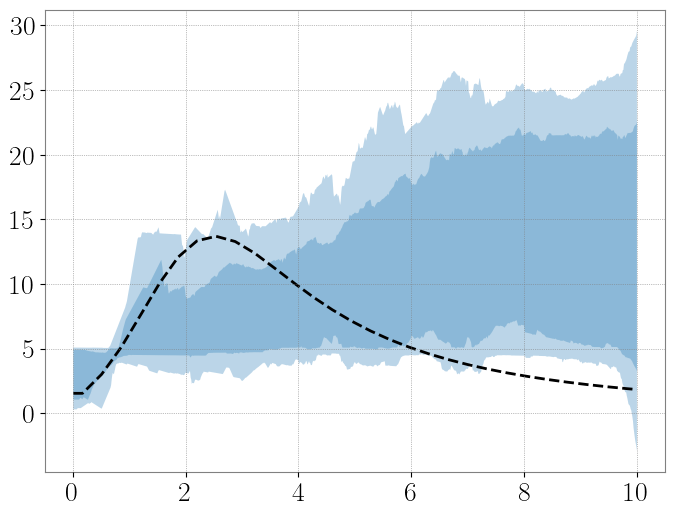

In [26]:
start = 5_000
num=100
skip = 10
plt.figure(figsize=(10, 6))
zs = np.linspace(0.01, 10, num=1000)
idxs = np.random.randint(start, len(cold_chain), num)  # Randomly select 500 samples
# idxs = np.linspace(start, len(cold_chain)-1, num=num).astype(int)
for i in idxs:
    state = cold_chain[i].state
    x, a = jpls(state.knots, state.heights, state.configuration)
    yvals = interpax.interp1d(zs, x, a, extrap=True, method='linear')
    plt.plot(zs, yvals, alpha=0.05, c='r')
plt.plot(zs, np.interp(zs, xvals, amplitudes), c='k', ls='--')
plt.ylim(0, 30)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Recovered Fits from Cold Chain (Parallel Tempering)")
plt.legend()
plt.show()

amps = []
for ii in np.arange(start, len(cold_chain), skip):
    state = cold_chain[ii].state
    x, a = jpls(state.knots, state.heights, state.configuration)
    # yvals = interpax.interp1d(zs, x, a, extrap=True, method='linear')
    tmp = interpax.interp1d(zs, x, a, extrap=True, method='linear')
    # plt.plot(zs, tmp, c='C0', alpha=0.1)
    amps.append(tmp)
print(np.percentile(np.array(amps), [16, 84], axis=0))
plt.plot(zs, np.interp(zs, xvals, amplitudes), c='k', ls='--')
plt.fill_between(zs, *np.percentile(np.array(amps), [16, 84], axis=0), alpha=0.3, facecolor='C0')
plt.fill_between(zs, *np.percentile(np.array(amps), [5, 95], axis=0), alpha=0.3, facecolor='C0')

In [27]:
start_zvals = np.array([Lambda_start[f'xvals{ii}'] for ii in range(max_knots)])
start_amplitudes = np.array([Lambda_start[f'amplitudes{ii}'] for ii in range(max_knots)])

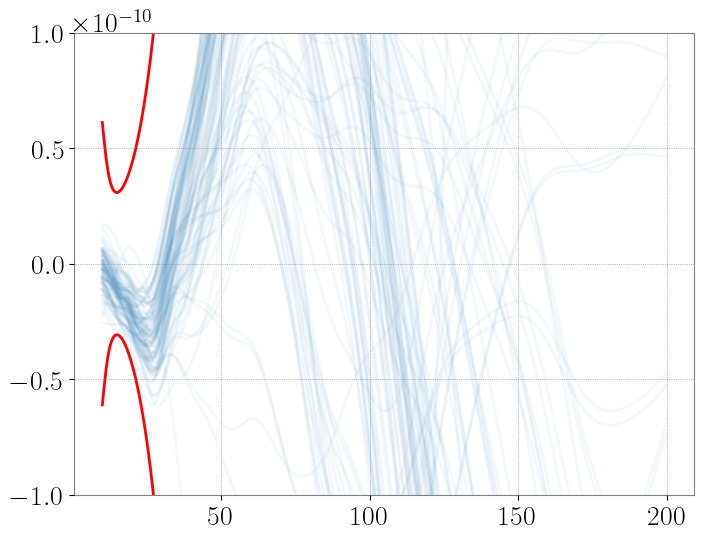

In [42]:
# plt.plot(freqs, inj_pop.omega_gw)
import copy
newlambda = copy.deepcopy(Lambda_start)
for idx in idxs:
    newlambda.update({f'configuration{ii}': cold_chain[idx].state.configuration[ii] for ii in range(max_knots)})
    newlambda.update({f'amplitudes{ii}': cold_chain[idx].state.heights[ii] for ii in range(max_knots)})
    newlambda.update({f'xvals{ii}': cold_chain[idx].state.knots[ii] for ii in range(max_knots)})
    plt.plot(freqs, injected_pop.omega_gw - jco(newlambda), c='C0', alpha=0.05)
plt.ylim(-1e-10, 1e-10)
plt.plot(freqs, -sigma, c='r')
plt.plot(freqs, sigma, c='r')

plt.show()

# Other sampler

In [28]:
# rs_sampler = RedshiftSampler(data_object, max_knots,
#                              [0.01, 10], [0, 30],
#                              min_knots=0, birth_gauss_scalefac=.05)
rs_sampler_jax = RedshiftSamplerJAX(data_object, max_knots,
                             [0.01, 10], [0, 30],
                             min_knots=2, birth_gauss_scalefac=0.1, birth_uniform_frac=0.3,
                                   )

In [29]:
rs_sampler_jax.set_base_population_information(jax.jit(calc_omgw), spline_pop, Lambda_start)

In [30]:
start_zvals = np.array([Lambda_start[f'xvals{ii}'] for ii in range(max_knots)])
start_amplitudes = np.array([Lambda_start[f'amplitudes{ii}'] for ii in range(max_knots)])

In [31]:
results2 = rs_sampler_jax.sample(20_000,
                            start_knots=start_zvals,
                            start_heights=start_amplitudes,
                            start_config=np.ones(max_knots).astype(bool),
                            proposal_weights=[1, 1, 1, 1, 1], 
                           )

starting ll: 8114.093336269408


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [01:22<00:00, 241.17it/s]


[[ 1.0545751   1.0545751   1.0545751  ...  3.45761112
   3.37735505  3.20798366]
 [ 4.90462342  4.90462342  4.90462342 ... 22.29916369
  22.36216662 22.54991953]]


(0.0, 50.0)

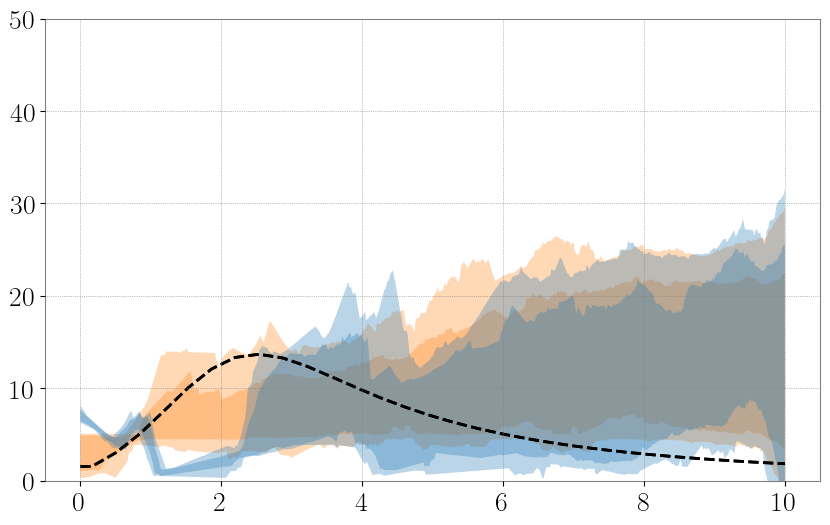

In [32]:
start = 2000
end = len(results2.lls)
skip = 10
amps = []


start = 5_000
num=100
skip = 10
plt.figure(figsize=(10, 6))
zs = np.linspace(0.01, 10, num=1000)
idxs = np.random.randint(start, len(cold_chain), num)  # Randomly select 500 samples
idxs = np.linspace(start, len(cold_chain)-1, num=num).astype(int)

amps = []
for ii in np.arange(start, len(cold_chain), skip):
    state = cold_chain[ii].state
    x, a = jpls(state.knots, state.heights, state.configuration)
    # yvals = interpax.interp1d(zs, x, a, extrap=True, method='linear')
    tmp = interpax.interp1d(zs, x, a, extrap=True, method='linear')
    # plt.plot(zs, tmp, c='C0', alpha=0.1)
    amps.append(tmp)
print(np.percentile(np.array(amps), [16, 84], axis=0))
plt.plot(zs, np.interp(zs, xvals, amplitudes), c='k', ls='--')
plt.fill_between(zs, *np.percentile(np.array(amps), [16, 84], axis=0), alpha=0.3, facecolor='C1')
plt.fill_between(zs, *np.percentile(np.array(amps), [5, 95], axis=0), alpha=0.3, facecolor='C1')

start = 15_000
num=100
skip = 1
amps = []
for ii in np.arange(start, end, skip):
    # xvals_tmp = results.knots[ii+offset, results.configurations[ii+offset, :].astype(bool)]
    # amplitudes_tmp = results.heights[ii+offset, results.configurations[ii+offset, :].astype(bool)]
    # plt.plot(zs, np.interp(zs, xvals_tmp, amplitudes_tmp), c='r', alpha=0.1)
    
    x, a = jpls(results2.knots[ii, :], results2.heights[ii, :], results2.configurations[ii, :])
    # a = propagate_last_selected(, results.configurations[ii+offset, :])
    tmp = interpax.interp1d(zs, x, a, extrap=True, method='linear')
    # plt.plot(zs, tmp, c='C0', alpha=0.1)
    amps.append(tmp)
plt.plot(zs, np.interp(zs, xvals, amplitudes), c='k', ls='--')
plt.fill_between(zs, *np.percentile(np.array(amps), [16, 84], axis=0), alpha=0.3, facecolor='C0')
plt.fill_between(zs, *np.percentile(np.array(amps), [5, 95], axis=0), alpha=0.3, facecolor='C0')
plt.ylim(0, 50)
# plt.plot(zs, np.interp(zs, start_zvals, start_amplitudes), c='g')

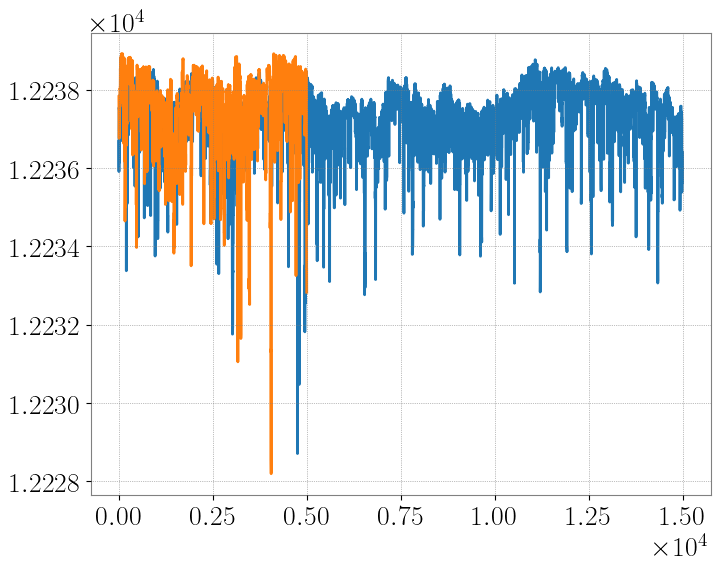

In [33]:
plt.plot(results2.lls[5000:])
plt.plot([cold_chain[ii].state.log_likelihood for ii in range(5000, len(cold_chain))])

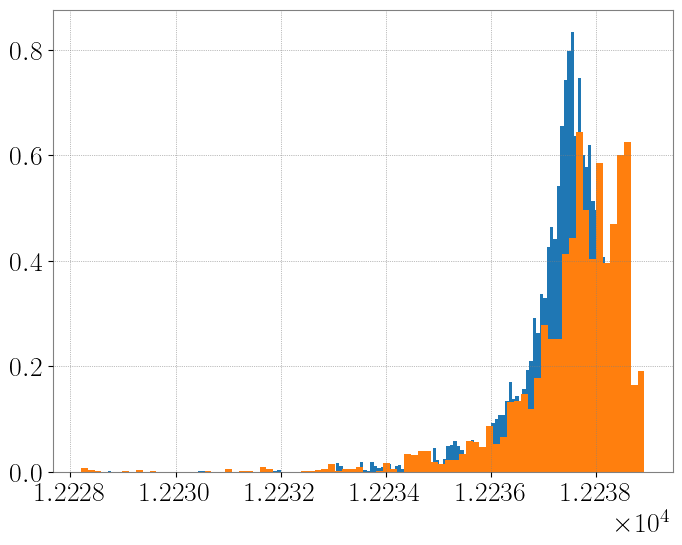

In [34]:
plt.hist(results2.lls[5000:], density=True, bins='auto')
plt.hist([cold_chain[ii].state.log_likelihood for ii in range(5000, len(cold_chain))], density=True, bins='auto')
plt.show()

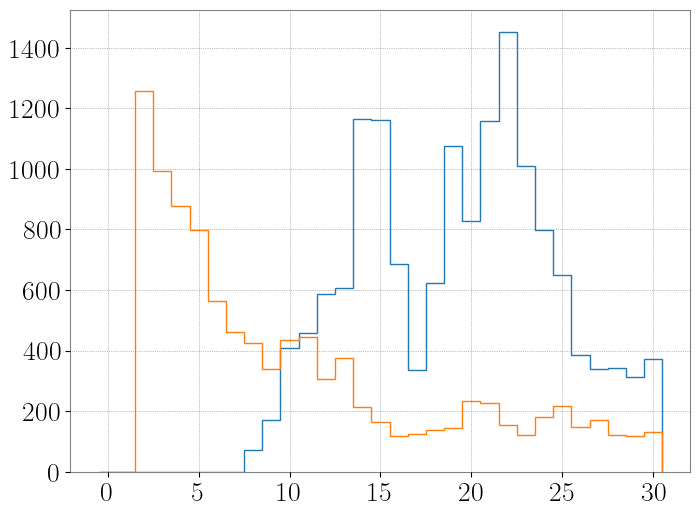

In [35]:
plt.hist(np.sum(results2.configurations[5000:], axis=1), bins=np.linspace(-0.5, 30.5, num=32), histtype='step')
plt.hist(nknots, bins=np.linspace(-0.5, 30.5, num=32), histtype='step')
plt.show()